In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np

In [85]:
file_path = 'data/interim/data_072024.csv'
df = pd.read_csv(file_path)
df.head()

,date,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,Zona
0,2024-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,CENTRO
1,2024-07-01 00:00:00,0.31,2.0,9.7,11.7,7.0,19.0,8.00,719.5,0.0,NaN,2.1,0.0,22.76,4.2,148.0,NORTE
2,2024-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,SURESTE
3,2024-07-01 01:00:00,0.41,1.8,5.8,7.9,14.0,27.0,6.52,714.6,0.0,87.0,2.3,0.0,21.56,7.5,35.0,CENTRO
4,2024-07-01 01:00:00,0.27,1.8,8.8,10.7,8.0,24.0,8.00,718.8,0.0,NaN,2.2,0.0,22.70,4.8,110.0,NORTE


In [86]:
cols=['date','CO','O3','NO', 'NO2','PM2.5',"NOX","PM10","SO2","WSR","WDR","Zona"]
df=df[cols]

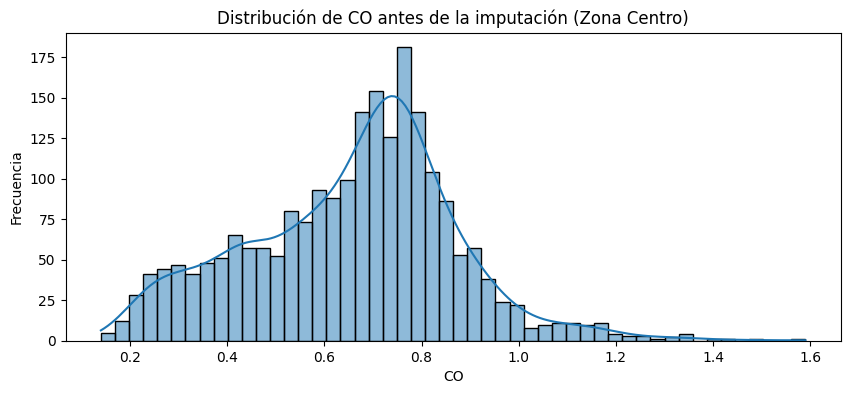

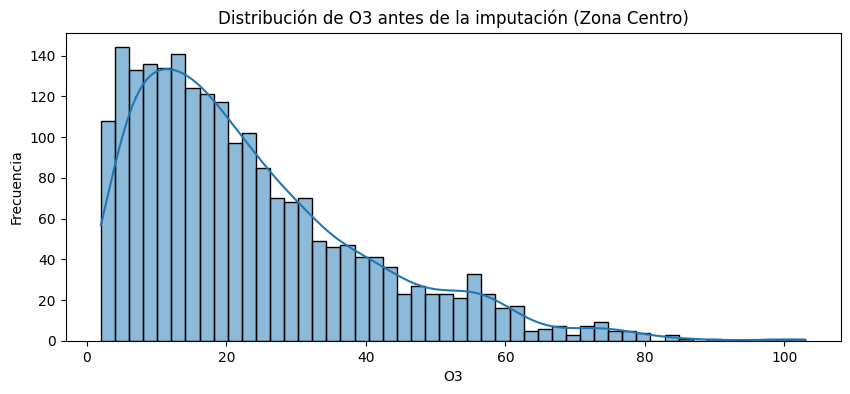

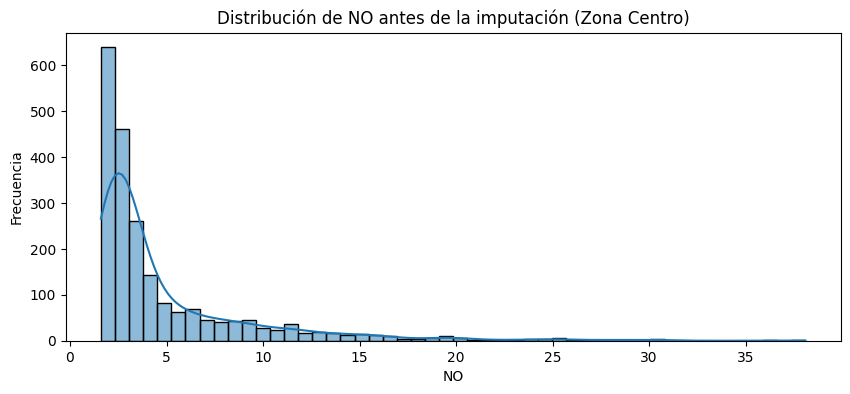

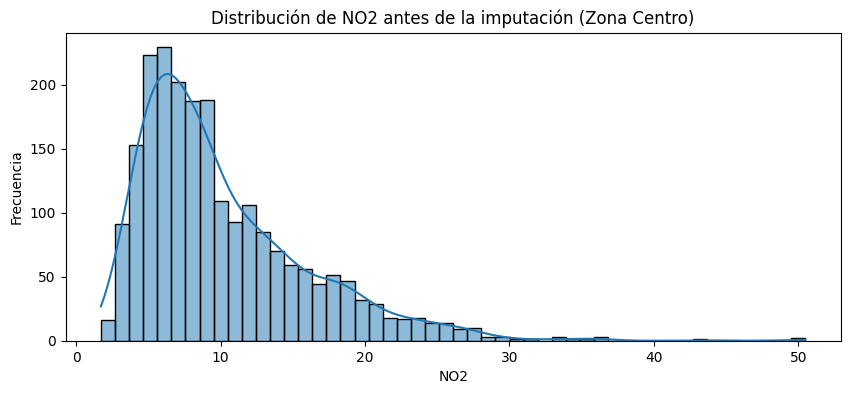

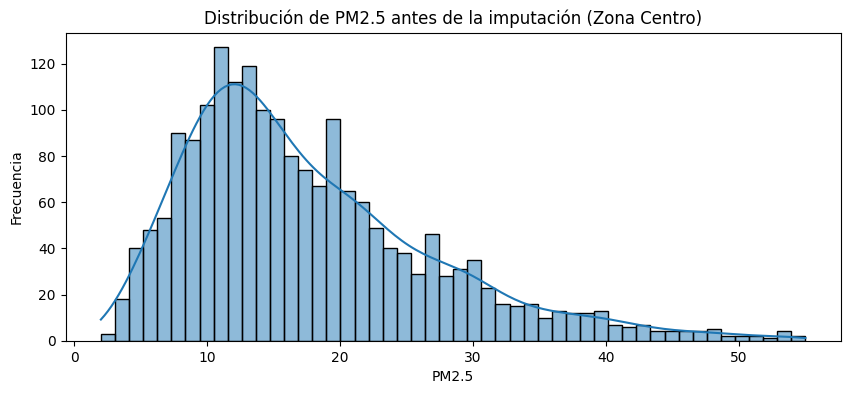

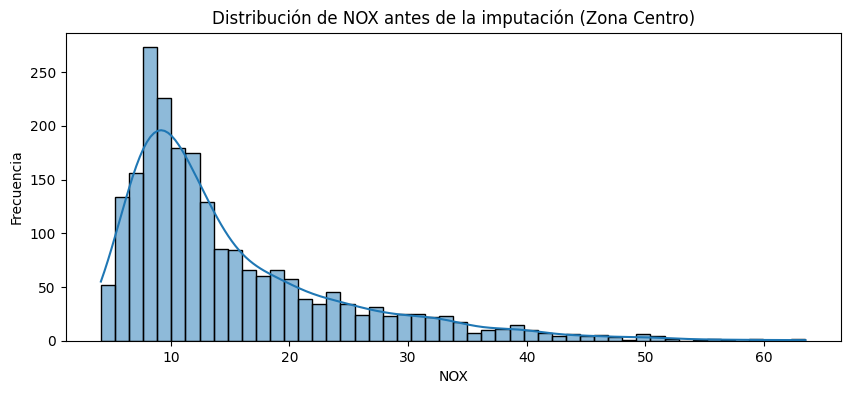

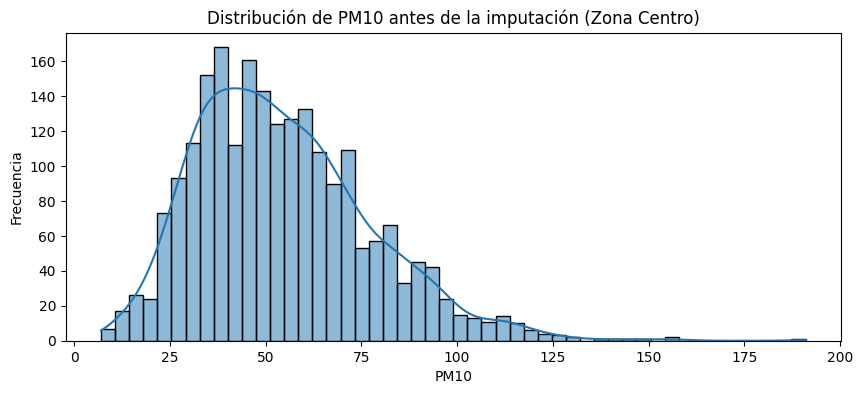

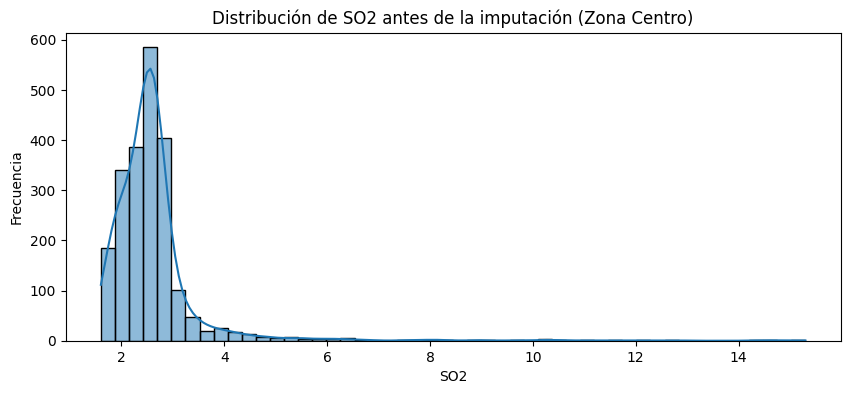

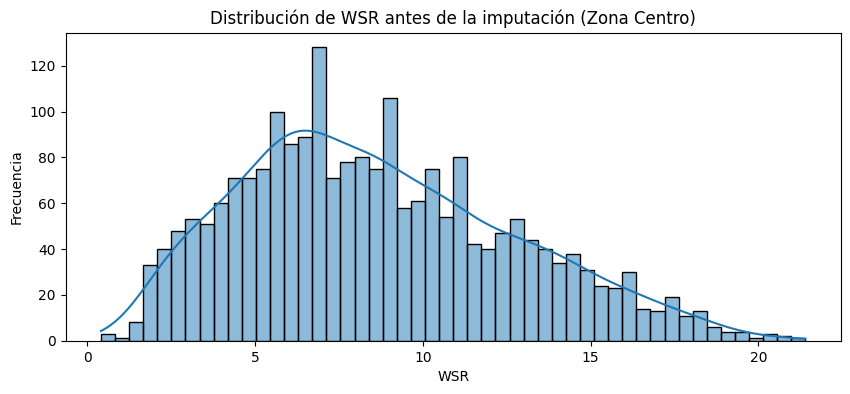

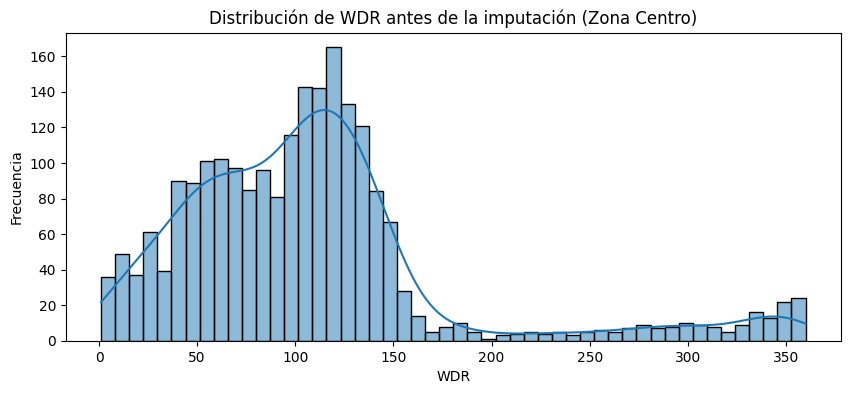

In [87]:
df_centro=df[df['Zona'] == "CENTRO"]
cols_num=['CO','O3','NO', 'NO2','PM2.5',"NOX","PM10","SO2","WSR","WDR"]
for col in cols_num:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f'Distribución de {col} antes de la imputación (Zona Centro)')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()  


--- Conteo Absoluto de Nulos por Zona ---
         date  CO  O3  NO  NO2  PM2.5  NOX  PM10  SO2  WSR  WDR  Zona
Zona                                                                 
CENTRO      0   2   5  20    2    109    2     4    7    2    2     0
NORTE       0  34  45  45   34     78   35    37   32   32   32     0
SURESTE     0   6   7  24    7    128    8     6   11    6    6     0


/var/folders/0p/t_nmy1zs1jgc_z9_lggdxk7m0000gn/T/ipykernel_88632/1545111319.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulls_by_zona = df.groupby('Zona').apply(lambda x: x.isna().sum())


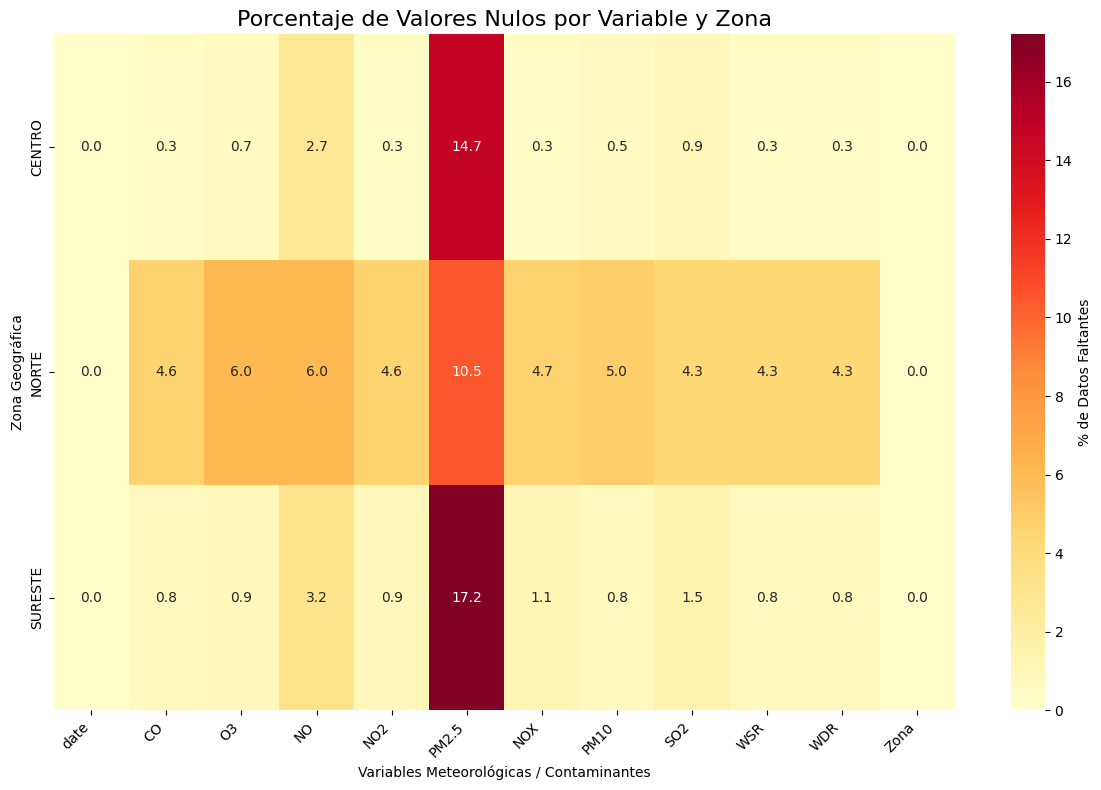

In [88]:
nulls_by_zona = df.groupby('Zona').apply(lambda x: x.isna().sum())

total_records_by_zona = df.groupby('Zona').size()
percent_nulls_by_zona = nulls_by_zona.div(total_records_by_zona, axis=0) * 100

print("--- Conteo Absoluto de Nulos por Zona ---")
print(nulls_by_zona)

# Visualización: Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(percent_nulls_by_zona, 
            annot=True, 
            fmt=".1f", 
            cmap="YlOrRd", 
            cbar_kws={'label': '% de Datos Faltantes'})

plt.title('Porcentaje de Valores Nulos por Variable y Zona', fontsize=16)
plt.ylabel('Zona Geográfica')
plt.xlabel('Variables Meteorológicas / Contaminantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [89]:
import pandas as pd
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

def imputar_series_meteo(df_input, max_gap_horas=4, metodo='time'):
    """
    Imputa valores faltantes en series de tiempo meteorológicas usando interpolación.
    
    Args:
        df_input (pd.DataFrame): DataFrame con índice DatetimeIndex.
        max_gap_horas (int): Número máximo de horas consecutivas a imputar. 
                             Si el hueco es mayor, se deja como NaN.
                             
        
    Returns:
        pd.DataFrame: Copia del DataFrame con datos imputados.
    """
    df = df_input.copy()
    cols_numericas = df.select_dtypes(include=[np.number]).columns
        
    for col in cols_numericas:
        nulos_antes = df[col].isna().sum()
        
        # APLICACIÓN DE LA INTERPOLACIÓN
        # method='time': considera la distancia real en el tiempo (útil si faltan filas enteras)
        # limit: cantidad máxima de NaNs consecutivos a llenar
        # limit_direction='both': intenta llenar hacia adelante y hacia atrás si el gap es pequeño
        df[col] = df[col].interpolate(method=metodo, 
                                      limit=max_gap_horas, 
                                      limit_direction='both')
        
        nulos_despues = df[col].isna().sum()
        
        if nulos_antes > 0:
            print(f"Variable '{col}': {nulos_antes - nulos_despues} datos recuperados. "
                  f"({nulos_despues} permanecen nulos por ser gaps grandes)")
            
    return df


In [90]:
def imputar_por_zona(df_general):
    """
    Toma el dataframe completo, separa por Zona, imputa individualmente 
    y vuelve a unir todo.
    """
    def procesar_grupo(df_zona):
        # Es vital ordenar por fecha para que la interpolación temporal funcione
        df_zona = df_zona.sort_index() 
        # Aplicamos la función de imputación que creamos antes
        return imputar_series_meteo(df_zona, max_gap_horas=4)

    # Esto separa (groupby), aplica la función (apply) y une los resultados automáticamente
    df_imputado = df_general.groupby('Zona', group_keys=False).apply(procesar_grupo)
    
    return df_imputado

df_limpio = imputar_por_zona(df)

print(f"Filas originales: {len(df)} | Filas finales: {len(df_limpio)}")

Variable 'CO': 2 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'O3': 5 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'NO': 20 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'NO2': 2 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'PM2.5': 42 datos recuperados. (67 permanecen nulos por ser gaps grandes)
Variable 'NOX': 2 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'PM10': 4 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'SO2': 7 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'WSR': 2 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'WDR': 2 datos recuperados. (0 permanecen nulos por ser gaps grandes)
Variable 'CO': 16 datos recuperados. (18 permanecen nulos por ser gaps grandes)
Variable 'O3': 27 datos recuperados. (18 permanecen nulos por ser gaps grandes)
Variable 'NO': 27 datos recuperados. (18 perman

/var/folders/0p/t_nmy1zs1jgc_z9_lggdxk7m0000gn/T/ipykernel_88632/4045710271.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_imputado = df_general.groupby('Zona', group_keys=False).apply(procesar_grupo)


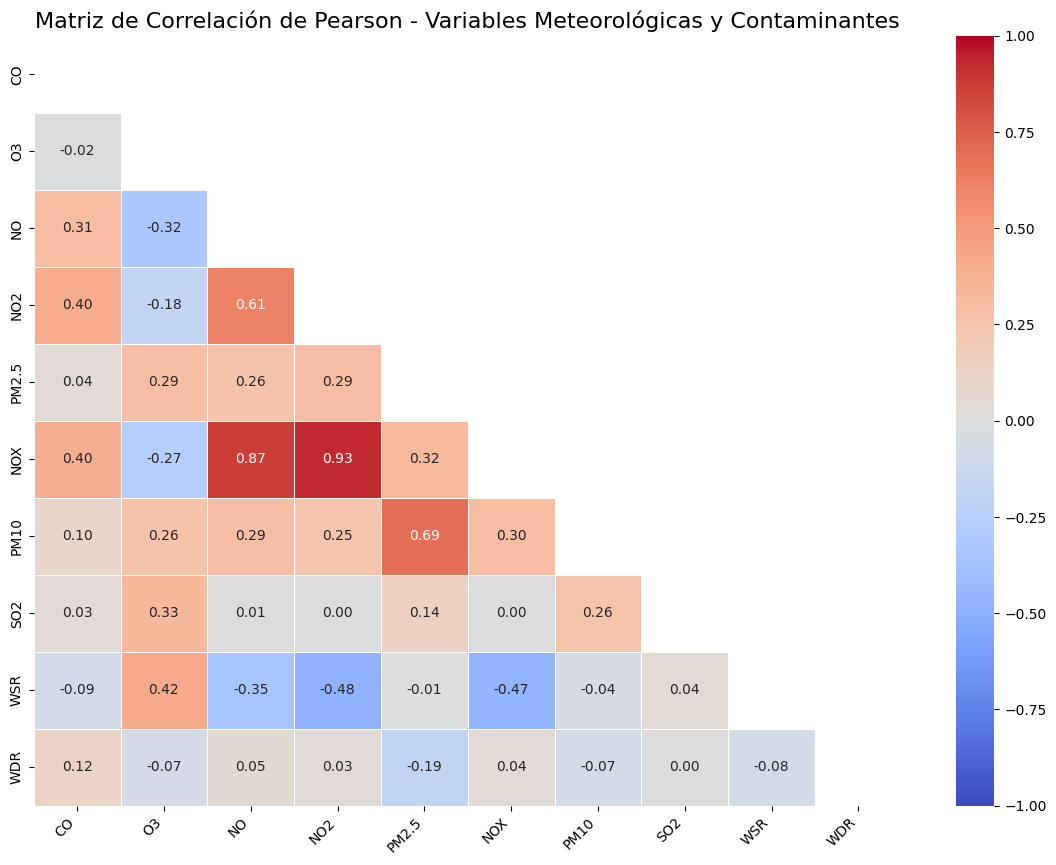

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Excluimos la columna 'Zona' ya que la correlación de Pearson solo funciona con números
df_corr = df_limpio.select_dtypes(include=['float64', 'int64'])

# .corr() ignora los NaNs automáticamente por pares (pairwise)
matriz_corr = df_corr.corr()
plt.figure(figsize=(14, 10))

# Usamos una máscara para ocultar la mitad superior (es un espejo, no aporta info extra)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr, 
            mask=mask,
            annot=True,              # Mostrar los números
            fmt=".2f",               # 2 decimales
            cmap='coolwarm',         # Azul (corr negativa) a Rojo (corr positiva)
            vmin=-1, vmax=1,         # Límites fijos para comparar colores justamente
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación de Pearson - Variables Meteorológicas y Contaminantes', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

La columna de WSR (Wind Speed / Velocidad del Viento) tiene una correlación negativa con todos los contaminantes ya que el viento "barre" la contaminación. Si hay mucho viento, la concentración de PM debería bajar.
Por otro lado, se observa una correlacion elevada entre las variables NOX y NO2 y PM10 y PM2.5

En meteorología urbana, los vehículos dejan una "huella digital" química muy clara:

CO (Monóxido de Carbono): Es el rey del tráfico. Proviene de la combustión incompleta de gasolina. Si ves picos de CO a las 8:00 AM y 7:00 PM, eso es tráfico puro.

NOx (Óxidos de Nitrógeno): Muy ligado a motores diésel (camiones, transporte público).

Relación entre ellos: A diferencia del Ozono (que depende del sol), estos dependen de la actividad humana directa.

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_final = df_limpio.copy()


df_final['Hora'] = df_final.index.hour

print(f"Nulos antes de imputación final: {df_final['CO'].isnull().sum()}")
# Función mágica: Rellenar nulos con la Mediana de esa misma variable, en esa misma Zona, a esa misma Hora.
vars_cols = df_final.select_dtypes(include=[np.number]).columns
# Iteramos por columna para rellenar
for col in vars_cols:
    if col != 'Hora': # No imputamos la hora consigo misma
        # Agrupamos por Zona y Hora, calculamos mediana y rellenamos nulos
        df_final[col] = df_final.groupby(['Zona', 'Hora'])[col].transform(
            lambda x: x.fillna(x.median())
        )

for col in vars_cols:
    if col != 'Hora':
         df_final[col] = df_final.groupby('Zona')[col].transform(
            lambda x: x.fillna(x.median())
        )

print(f"Nulos después de imputación final: {df_final['CO'].isnull().sum()}")


Nulos antes de imputación final: 18
Nulos después de imputación final: 0


mputación por "Perfil Horario Típico" Si nos falta el dato de CO del martes a las 8:00 AM en el Centro, lo más inteligente no es usar el dato de las 7:00 AM (interpolación), sino usar la mediana histórica de todas las 8:00 AM en el Centro.

--- Conteo Absoluto de Nulos por Zona ---
         CO  O3  NO  NO2  PM2.5  NOX  PM10  SO2  WSR  WDR  Zona  Hora
Zona                                                                 
CENTRO    0   0   0    0      0    0     0    0    0    0     0     0
NORTE     0   0   0    0      0    0     0    0    0    0     0     0
SURESTE   0   0   0    0      0    0     0    0    0    0     0     0


/var/folders/0p/t_nmy1zs1jgc_z9_lggdxk7m0000gn/T/ipykernel_88632/126928633.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulls_by_zona = df_final.groupby('Zona').apply(lambda x: x.isna().sum())


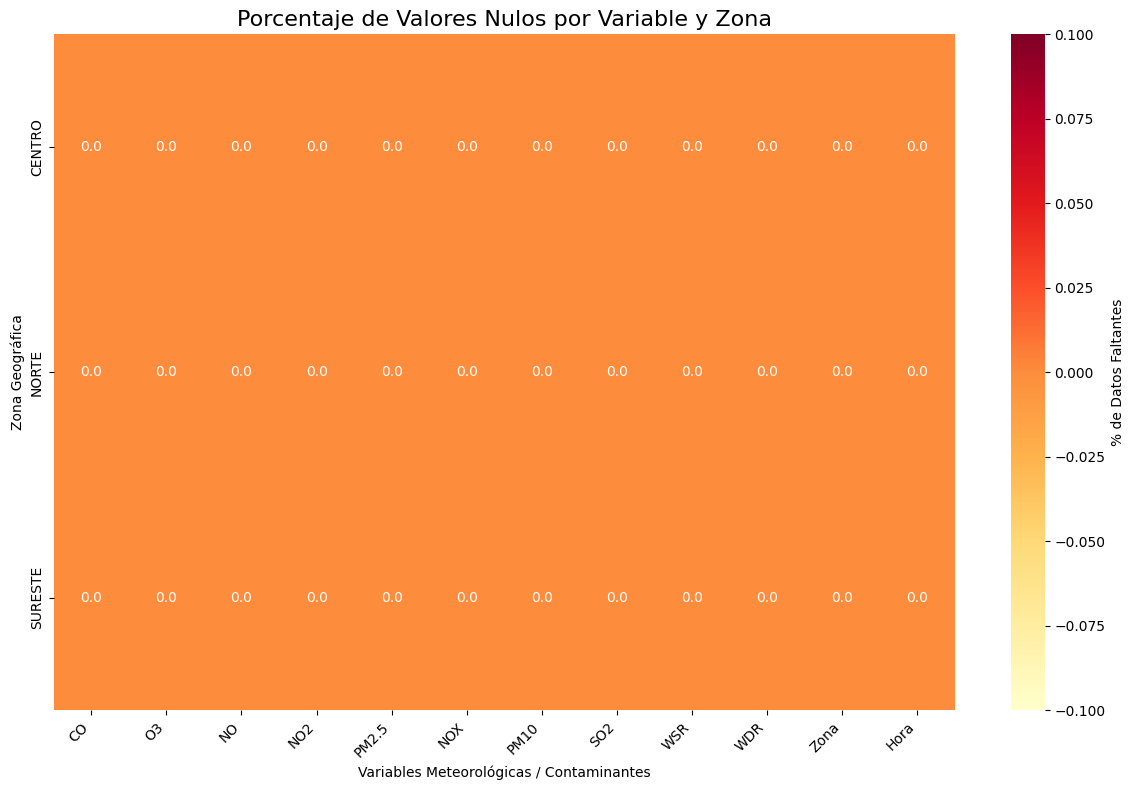

In [93]:
nulls_by_zona = df_final.groupby('Zona').apply(lambda x: x.isna().sum())

total_records_by_zona = df_final.groupby('Zona').size()
percent_nulls_by_zona = nulls_by_zona.div(total_records_by_zona, axis=0) * 100

print("--- Conteo Absoluto de Nulos por Zona ---")
print(nulls_by_zona)

# Visualización: Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(percent_nulls_by_zona, 
            annot=True, 
            fmt=".1f", 
            cmap="YlOrRd", 
            cbar_kws={'label': '% de Datos Faltantes'})

plt.title('Porcentaje de Valores Nulos por Variable y Zona', fontsize=16)
plt.ylabel('Zona Geográfica')
plt.xlabel('Variables Meteorológicas / Contaminantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

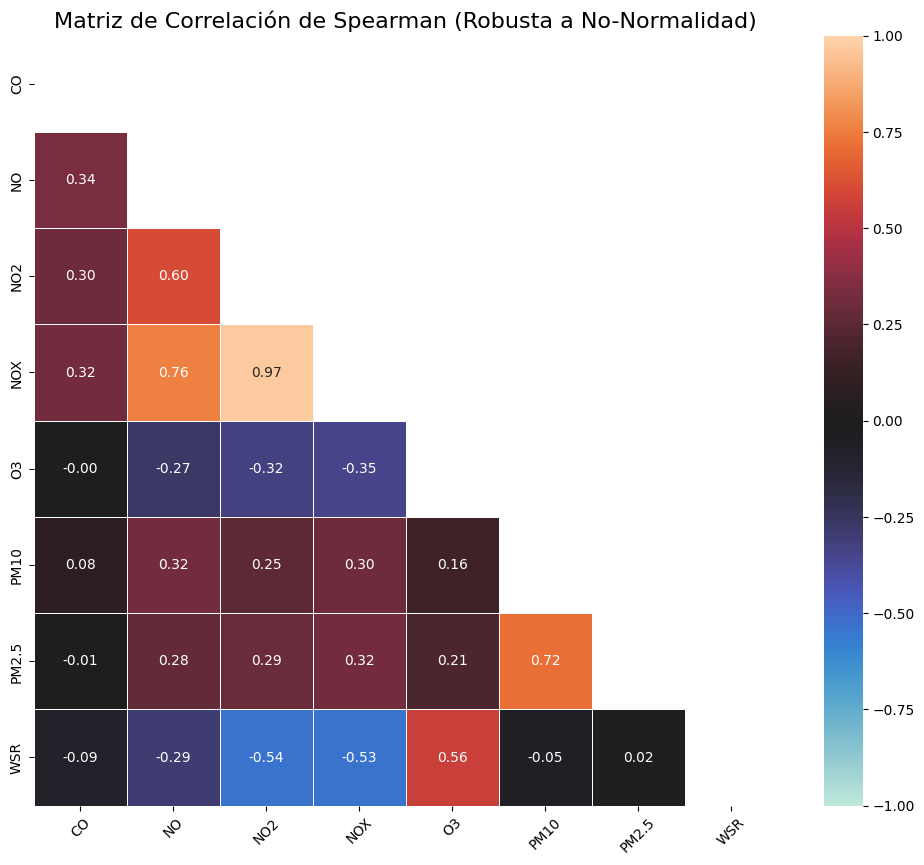

In [94]:
cols_interes = ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'WSR']
df_corr = df_final[cols_interes]

# Calculamos correlación usando method='spearman'
matriz_spearman = df_corr.corr(method='spearman')

# Visualización
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matriz_spearman, dtype=bool))

sns.heatmap(matriz_spearman, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='icefire', # Un mapa de color divergente y nítido
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title('Matriz de Correlación de Spearman (Robusta a No-Normalidad)', fontsize=16)
plt.xticks(rotation=45)
plt.show()

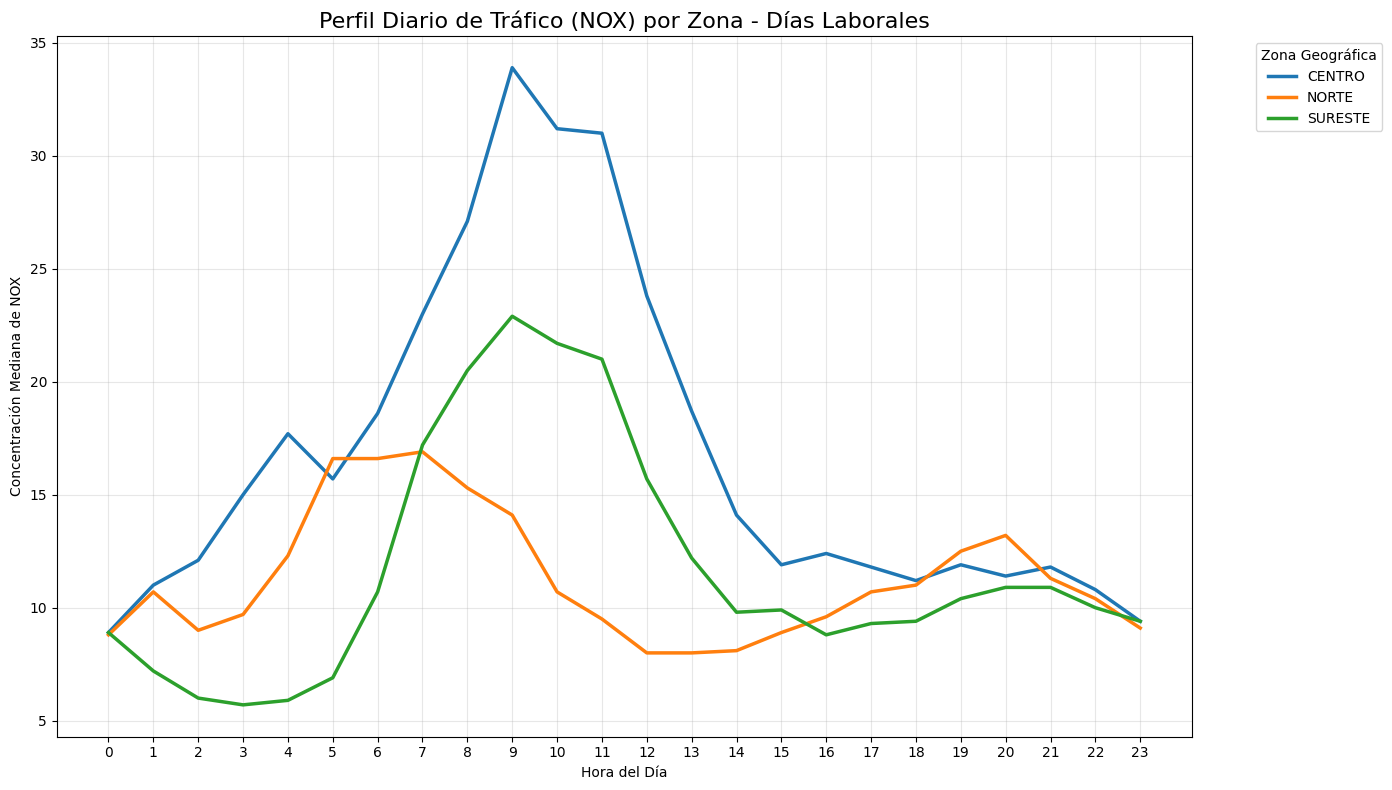

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Usamos el dataframe imputado, asegurando que el índice es datetime
df_analisis = df_final.copy()
df_analisis['Hora'] = df_analisis.index.hour

# Filtramos solo para días 'Entre Semana' para ver el tráfico laboral puro
# (0=Lunes, 4=Viernes)
df_laboral = df_analisis[df_analisis.index.dayofweek <= 4]

plt.figure(figsize=(14, 8))

# LINEPLOT: Es ideal para series de tiempo cíclicas
# hue='Zona': Dibujará una línea de color por cada zona
# estimator='median': Usamos la mediana porque tus datos NO son normales (es más robusto)
sns.lineplot(data=df_laboral, 
             x='Hora', 
             y='NOX', 
             hue='Zona', 
             estimator='median',  # Clave: Mediana en vez de Media
             errorbar=None,       # Quitamos la sombra de confianza para limpiar el gráfico
             linewidth=2.5,
             palette='tab10')

plt.title('Perfil Diario de Tráfico (NOX) por Zona - Días Laborales', fontsize=16)
plt.ylabel('Concentración Mediana de NOX')
plt.xlabel('Hora del Día')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24)) # Mostrar todas las horas
plt.legend(title='Zona Geográfica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

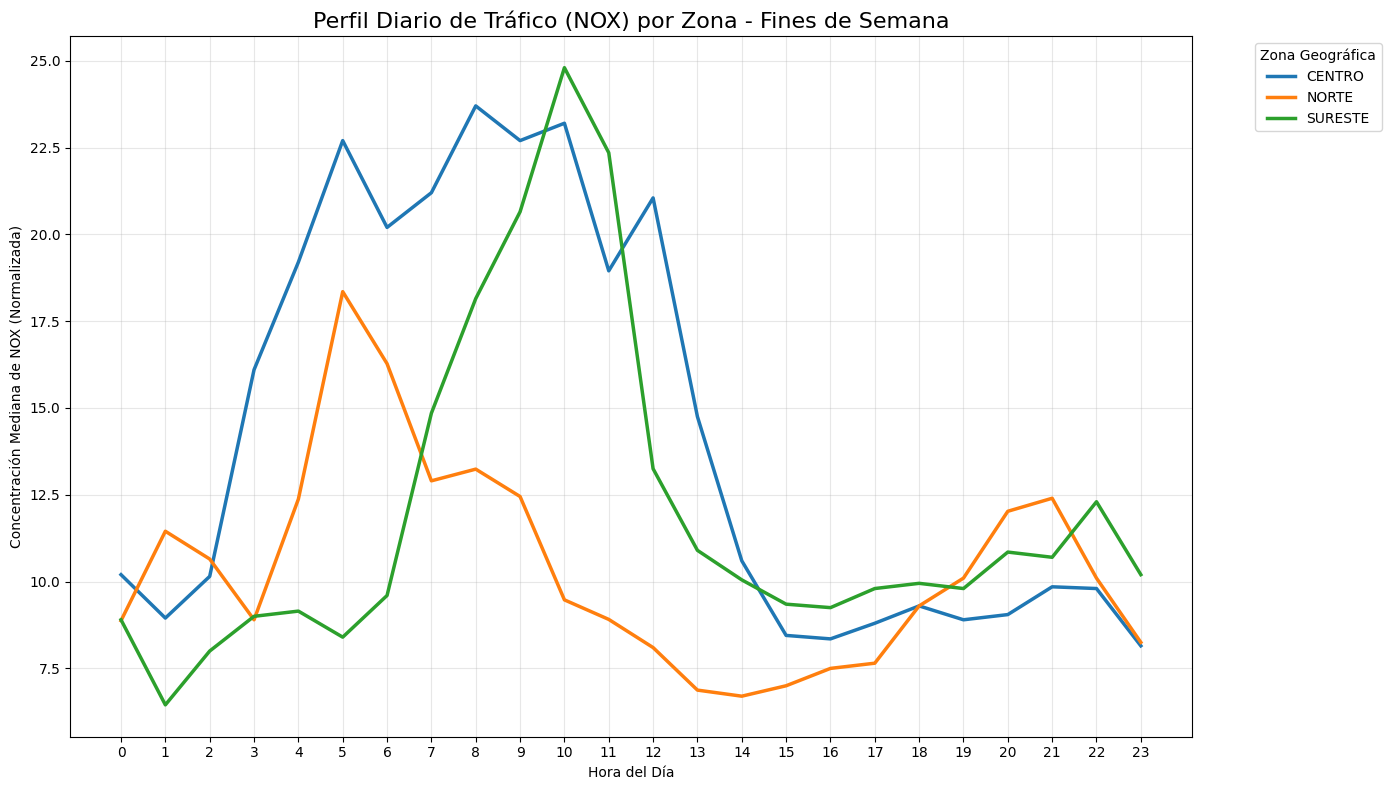

In [104]:

# 1. SOLUCIÓN AL ERROR: Resetear el índice para hacerlo único
# Esto mueve la fecha a una columna y crea un índice numérico 0, 1, 2...
df_analisis = df_final.copy()
df_libre = df_analisis[df_analisis.index.dayofweek > 4]
df_libre_plot = df_libre.reset_index()

# 2. Ahora sí, graficamos con el dataframe seguro
plt.figure(figsize=(14, 8))

sns.lineplot(data=df_libre_plot,  # Usamos el df con índice reseteado
             x='Hora', 
             y='NOX', 
             hue='Zona', 
             estimator='median', 
             errorbar=None, 
             linewidth=2.5,
             palette='tab10')

plt.title('Perfil Diario de Tráfico (NOX) por Zona - Fines de Semana', fontsize=16)
plt.ylabel('Concentración Mediana de NOX (Normalizada)')
plt.xlabel('Hora del Día')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.legend(title='Zona Geográfica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [106]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Definir las variables que entran al modelo
# Excluimos 'Zona' (categórica) y 'Hora' (cíclica/feature engineering)
cols_features = ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR']

# Verificamos que existan en tu df actual
features_disponibles = [c for c in cols_features if c in df_limpio.columns]

# 2. Separar los datos
X = df_limpio[features_disponibles]

# 3. Aplicar StandardScaler
# Fórmula: z = (x - media) / desviacion_estandar
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# 4. Reconstruir el DataFrame (Vital para no perder las fechas y nombres de columnas)
df_normalizado = pd.DataFrame(
    X_scaled_array, 
    columns=features_disponibles, 
    index=df_limpio.index
)

# Agregamos de vuelta la etiqueta 'Zona' para poder colorear los gráficos después
df_normalizado['Zona'] = df_limpio['Zona']

# --- VERIFICACIÓN DE CALIDAD ---
print("--- Verificación de Estandarización ---")
print("Media (debe ser aprox 0):")
print(df_normalizado[features_disponibles].mean().head(3).round(2))
print("\nDesviación Estándar (debe ser 1):")
print(df_normalizado[features_disponibles].std().head(3).round(2))

print("\n¡Datos listos para PCA!")

--- Verificación de Estandarización ---
Media (debe ser aprox 0):
CO    -0.0
NO     0.0
NO2    0.0
dtype: float64

Desviación Estándar (debe ser 1):
CO     1.0
NO     1.0
NO2    1.0
dtype: float64

¡Datos listos para PCA!
